# Transects and transport

This notebook demonstrates 

* how to define an oceanographic section,
* compute volume, heat, salt and freshwater transports through HYCOM output,
* visualise the spatial structure of transport across the section.

**Functions covered**

| Function | Purpose |
|---|---|
| `xhycom.Transect` | Define a section from (lon, lat) waypoints |
| `Transect.resolve(grid)` | Snap the section to the HYCOM C-grid |
| `Transect.reverse()` | Flip the sign convention by reversing waypoint order |
| `xhycom.transport()` | Volume / heat / salt / freshwater transport through HYCOM |
| `xhycom.section_data()` | Hydrographic cross-section (T-point fields) |
| `xhycom.section_flux_density()` | Per-face, per-layer transport density |
| `xhycom.section_plot()` | 2-D section visualisation |

**See also:** [comparison_transects_transports.ipynb](comparison_transects_transports.ipynb) — comparing these HYCOM results against GLORYS using different strategies.

In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"

In [3]:
grid = xhycom.open_dataset(GRID_PATH)
bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

## 1. Define and resolve a transect

A `Transect` is a sequence of (lon, lat) waypoints and knows nothing about any particular model grid — the same object can be resolved against any grid, including any HYCOM and any lat-lon grid.

Calling `Transect.resolve(grid)` does two things:

- **T-cell path**: finds the ordered T-cells the section polyline passes through, used by `section_data` to extract hydrographic fields.
- **C-grid faces**: identifies the exact U- and V-face crossings, used by `transport` and `section_flux_density` to integrate transport without rotating or interpolating velocities.

Several common Arctic and sub-Arctic sections are built in:

In [4]:
# Available named sections
xhycom.Transect.available_names()

['barents_kara_northern_boundary',
 'barents_opening',
 'bering_strait',
 'davis_strait',
 'denmark_strait',
 'fram_strait',
 'fsc',
 'gimsoy',
 'hudson_strait',
 'jones_strait',
 'kara_gate',
 'kola_section',
 'lancaster_sound',
 'robeson_channel',
 'svinoy']

Use `Transect.named()` to retrieve a built-in section:

In [5]:
fs = xhycom.Transect.named("fram_strait")
fs

Transect('fram_strait', 2 waypoints)

Built-in zonal sections are defined east → west, so positive transport is northward.  The Fram Strait waypoints are:

In [6]:
fs.lons

array([ 15., -20.])

In [7]:
fs.lats

array([79., 79.])

> **Sign convention** — positive transport is **rightward** when walking from the first to the last waypoint.
>
> Built-in zonal sections are defined east → west, so north is on your right and positive means northward:
>
> | Sign | Physical meaning at Fram Strait |
> |---|---|
> | positive | northward — Atlantic inflow (West Spitsbergen Current) |
> | negative | southward — Arctic outflow (East Greenland Current) |
>
> Call `fs.reverse()` to adopt the opposite convention (positive = southward).

You can also pass waypoints directly.  The sign convention is set entirely by their order — the example below uses the original west-to-east orientation (positive = southward), which shows both conventions are equally valid:

In [8]:
custom = xhycom.Transect(lons=[-20, 15], lats=[79, 79], name="My Fram Strait")
custom

Transect('My Fram Strait', 2 waypoints)

Now resolve against the HYCOM grid.  This is the step that ties the section geometry to a specific model grid.  The resolved object stores the T-cell path, face indices, face signs, and along-section distances — everything needed for transport and section-data calculations.

**Resolve once, reuse many times**: `resolve()` builds a KD-tree over the full T-point grid and should be called once per grid.  Pass the `ResolvedTransect` to all subsequent `transport()`, `section_data()`, and `section_flux_density()` calls.

The three plots below show the section at increasing zoom: the full domain view, a regional view around Fram Strait, and a close-up where individual T-cells and the U/V face staircase are visible.

In [9]:
fs_on_hycom = fs.resolve(grid)

In [10]:
print(f"T-cells along section : {fs_on_hycom.n_cells}")
print(f"C-grid faces crossed  : {fs_on_hycom.n_faces}")
print(f"Section length        : {fs_on_hycom.distance_km[-1]:.0f} km")

T-cells along section : 57
C-grid faces crossed  : 56
Section length        : 1035 km


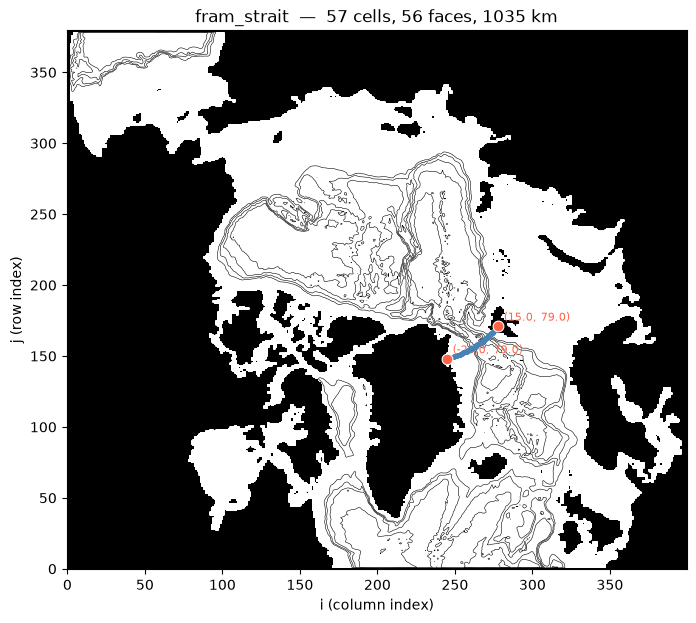

In [11]:
fs_on_hycom.plot(grid=grid, bathy=bathy, figsize=(8, 7))

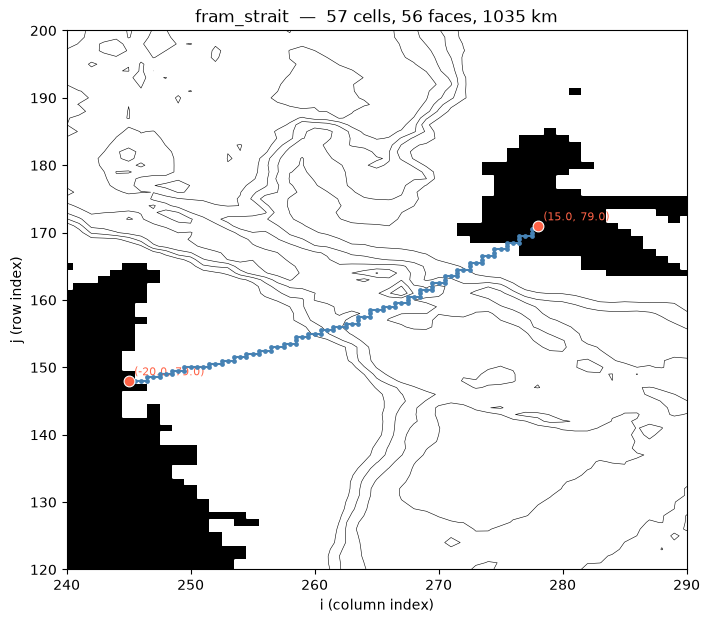

In [12]:
fs_on_hycom.plot(grid=grid, bathy=bathy, i_range=(240, 290), j_range=(120, 200), figsize=(8, 7))

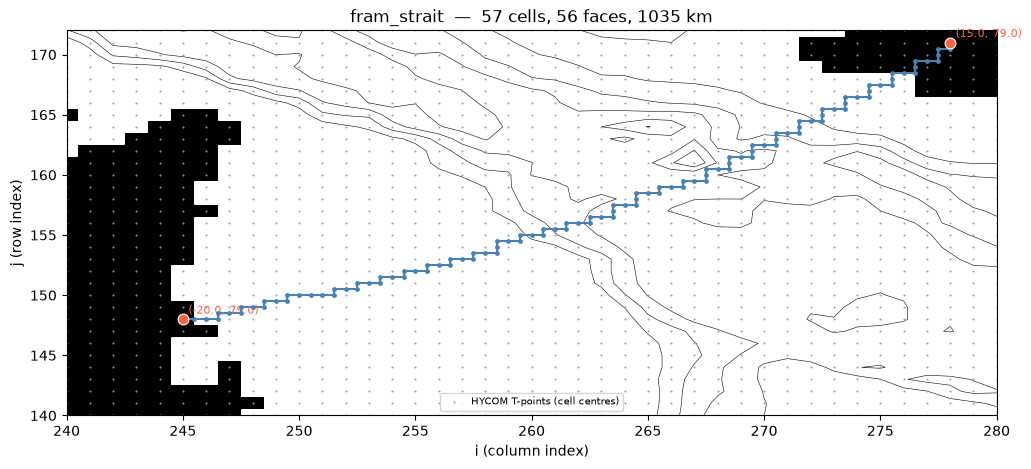

In [13]:
fs_on_hycom.plot(grid=grid, bathy=bathy, show_cells=True, i_range=(240, 280), j_range=(140, 172), figsize=(12, 5))

Here is a plot of all pre-defined sections resolved on the TOPAZ 2 grid.

In [14]:
named_resolved = {
    name: xhycom.Transect.named(name).resolve(grid)
    for name in xhycom.Transect.available_names()
}

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

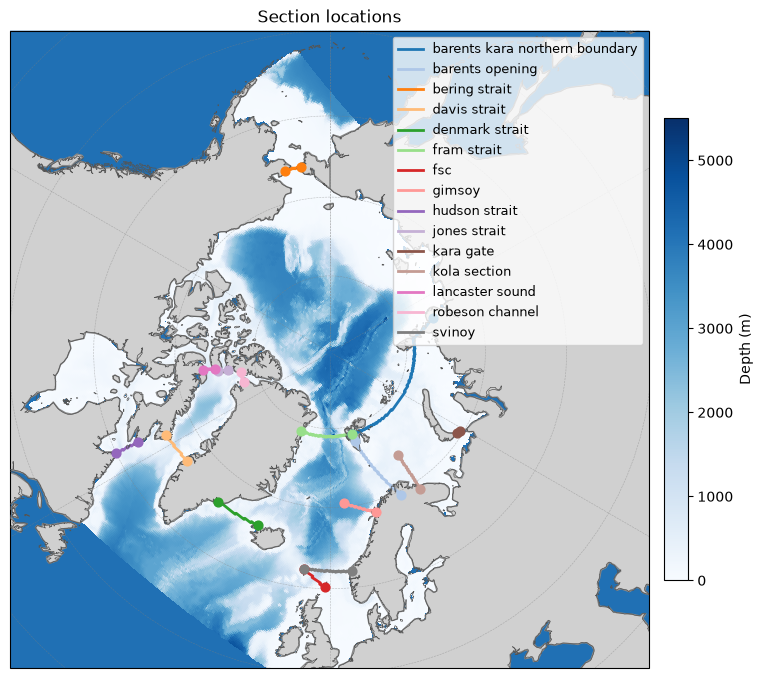

In [16]:
proj = ccrs.NorthPolarStereo(central_longitude=0.0)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

cmap = plt.cm.Blues.copy()
cmap.set_bad("none")
pcm = ax.pcolormesh(
    bathy.lon.values, bathy.lat.values, bathy["depth"].values,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=0, vmax=5500, shading="nearest", zorder=1,
)
plt.colorbar(pcm, ax=ax, shrink=0.6, pad=0.02, label="Depth (m)")

ax.add_feature(cfeature.LAND, facecolor="#d0d0d0", edgecolor="#888", zorder=2)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="#555", linewidth=0.5, zorder=3)
ax.gridlines(linewidth=0.4, linestyle="--", color="grey", alpha=0.5)

colors = plt.cm.tab20.colors
for idx, (name, rt) in enumerate(named_resolved.items()):
    col = colors[idx % len(colors)]
    ax.plot(rt.cell_lon, rt.cell_lat, transform=ccrs.PlateCarree(),
            color=col, lw=2, label=name.replace("_", " "))
    ax.scatter(rt.cell_lon[[0, -1]], rt.cell_lat[[0, -1]],
               transform=ccrs.PlateCarree(), color=col, s=40, zorder=5)

ax.legend(loc="upper right", fontsize=9, framealpha=0.8)
ax.set_title("Section locations", fontsize=12)
plt.tight_layout()

## 2. Volume, heat, salt and freshwater transport

In [17]:
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

KeyboardInterrupt: 

`transport()` integrates velocity and tracer fields over the resolved C-grid faces.  It uses `u-vel.` and `v-vel.` directly at their staggered U/V face locations — no rotation to T-points is needed.  Layer thickness and tracer values are averaged from the two T-cells straddling each face.

> **Always postprocess** — open HYCOM archives with `postprocess=True` or call `xhycom.postprocess(ds)` explicitly.  Without it, `u-vel.` contains only the baroclinic component and transports will be wrong.  This applies to both instantaneous (`archv.*`) and time-averaged (`archm.*`) archives.

> **Thickness units** — `thknss` is stored in Pa in HYCOM archives.  `postprocess` converts it to metres; `transport()` and `section_data()` auto-detect both units, so either form works.

In [ ]:
%time tr = xhycom.transport(ds, fs_on_hycom)

The result is a small `xr.Dataset` with one scalar time series per transport variable.

Note that the call returns instantly because all arrays are Dask-backed — no data has been computed yet.  Computation is deferred until explicitly requested.

In [ ]:
tr

Loading all four transport variables for a full year triggers the actual computation.  Wall time scales with the number of time steps; chunking by time (as done above) keeps memory usage low.

In [ ]:
%time tr.load()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

tr.volume.plot(ax=axs[0, 0])
tr.heat.plot(ax=axs[0, 1])
tr.salt.plot(ax=axs[1, 0])
tr.fw.plot(ax=axs[1, 1])

for ax in axs.flatten():
    ax.grid()
    
plt.tight_layout()

### Constrained transports — separating water masses

Pass `constraints` to zero out face-layer contributions where a tracer condition is not met.  Multiple constraints are AND-ed.  The tracer value at each face is the average of the two neighbouring T-cells.

This cleanly separates inflow and outflow by water-mass class.  By construction the constrained transports sum to the total: `tr_aw + tr_pw ≈ tr`.

In [ ]:
%%time

# Atlantic Water: T > 1 °C
tr_aw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("gt", 1.0)}).compute()
# Polar/Arctic Water: T ≤ 1 °C
tr_pw = xhycom.transport(ds, fs_on_hycom, constraints={"temp": ("le", 1.0)}).compute()

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

tr.volume.plot(ax=axs[0, 0], color="k", label="total")
tr_aw.volume.plot(ax=axs[0, 0], label="T > 1 °C")
tr_pw.volume.plot(ax=axs[0, 0], label="T ≤ 1 °C")

tr.heat.plot(ax=axs[0, 1], color="k", label="total")
tr_aw.heat.plot(ax=axs[0, 1], label="T > 1 °C")
tr_pw.heat.plot(ax=axs[0, 1], label="T ≤ 1 °C")

tr.salt.plot(ax=axs[1, 0], color="k", label="total")
tr_aw.salt.plot(ax=axs[1, 0], label="T > 1 °C")
tr_pw.salt.plot(ax=axs[1, 0], label="T ≤ 1 °C")

tr.fw.plot(ax=axs[1, 1], color="k", label="total")
tr_aw.fw.plot(ax=axs[1, 1], label="T > 1 °C")
tr_pw.fw.plot(ax=axs[1, 1], label="T ≤ 1 °C")


for ax in axs.flatten():
    ax.grid()
    ax.legend()
    
plt.tight_layout()

---

## 3. Hydrographic cross-section

`section_data()` extracts any model variable along the T-cell path, returning a `(section, k)` Dataset with `distance_km` and `depth_m` coordinates ready for cross-section plots.  The `section` dimension spans the T-cells identified by `resolve()`; `distance_km` is the cumulative great-circle distance from the first T-cell.

> **Variable selection** — by default `section_data()` extracts every variable in the dataset.  Pass `variables=["temp", "salin"]` to load only what you need — important for large archives.

In [ ]:
sec = xhycom.section_data(ds, fs_on_hycom)
sec

In [ ]:
sec0 = sec.isel(time=0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec0, "temp", 
    ax=axes[0],
    cmap="RdYlBu_r",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Temperature (°C)"
)

xhycom.section_plot(
    sec0, "salin", 
    ax=axes[1],
    cmap="viridis",
    depth_max=3000,
    flip_x=True, # flip section orientation to west to east
    title="Salinity (PSU)"
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

> **x-axis orientation** — the x-axis runs from east (left, 0 km) to west (right, ~1035 km), matching the east → west waypoint order of the built-in Fram Strait transect.  To show the Fram Strait with west on the left in the above plot, we passed `flip_x=True` to `section_plot`.

---

## 4. Transport structure — where does the transport come from?

`section_flux_density()` returns the **signed transport density** `v_normal × dz` (m² s⁻¹) at every C-grid face and vertical layer.  The sign follows the same rightward convention as `transport()`.

Integrating: `(flux_density × face_width_m).sum(["k", "face"])` recovers the total volume transport from `tr.volume`.  Plotting the unintegrated density reveals the spatial structure — which part of the section and which depth range carries the inflow vs outflow.

> **Note**: `heat_flux_density`, `salt_flux_density`, and `fw_flux_density` are the corresponding tracer-weighted fields.  The same integration recovers `tr.heat`, `tr.salt`, and `tr.fw` (after applying the same unit scale factors as `transport()`).  See the `section_flux_density` docstring for details.

In [ ]:
sec_flux = xhycom.section_flux_density(ds, fs_on_hycom)
sec_flux

In [ ]:
sec_flux0 = sec_flux.isel(time=0)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xhycom.section_plot(
    sec_flux0, "flux_density", 
    ax=axes[0],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Volume transport density (positive = rightward/northward)",
)

xhycom.section_plot(
    sec_flux0, 
    "heat_flux_density", 
    ax=axes[1],
    depth_max=3000, 
    flip_x=True, # flip section orientation to west to east
    cmap="RdYlBu_r",
    center_zero=True,
    title="Heat transport density  (positive = rightward/northward)",
)

fig.suptitle(f"Fram Strait cross-section on {sec0.time.values.item()}", fontsize=13)
plt.tight_layout()

To compare these results against a reanalysis product such as GLORYS, see [comparison_transects_transports.ipynb](comparison_transects_transports.ipynb).